Here, I will demonstrate how we can generate a sample using `galpy` and get it into the form needed for `Simulation` using included functions.

In [6]:
from galpy.potential import PlummerPotential
from galpy.df import isotropicPlummerdf
import matplotlib.pyplot as plt
import astropy.units as u
from ezfalcon.util import galpydfsampler

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [7]:
pot = PlummerPotential(amp=1e11*u.Msun, b=2*u.kpc)
df = isotropicPlummerdf(pot=pot)
pos, vel, masses = galpydfsampler(df, n=10000, m_total=1e11)

Text(0.5, 1.0, 'Isotropic Hernquist DF Sampling')

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

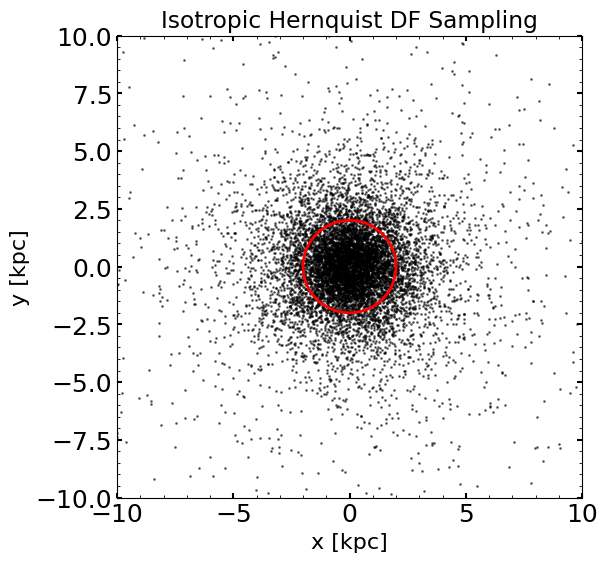

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(pos[:,0], pos[:,1], s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
plt.gca().add_artist(circle)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Isotropic Hernquist DF Sampling')

In [9]:
from ezfalcon.simulation import Sim
sim = Sim()
sim.add_particles('hernquist', pos, vel, mass=masses)

With this, we can easily calculate the virial ratio to show that the sample is from an equilibrium distribution.

In [10]:
#plt.hist(sim.vx(), bins=50, density=True)